In [ ]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
from scipy.stats import entropy
import math

In [ ]:
ruta = '/content/diabetic_data.csv'
df = pd.read_csv(ruta, na_values=['?'])
df.head()

/tmp/ipykernel_5463/3936444695.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, na_values=['?'])


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Funciones auxiliares ( las dejo aca para que sea mas facil cambiarlas )

def entropia_categoricas(data, columnas=None, base=2, dropna=True, figsize=(10, 6),
                         mostrar=True, decimales=3):
    """Entropía de Shannon, entropía máxima y uniformidad de cada variable categórica."""
    if columnas is None:
        columnas = [c for c in data.select_dtypes(include=['category', 'object', 'bool']).columns
                    if data[c].nunique(dropna=True) <= 30]
    elif isinstance(columnas, str):
        columnas = [columnas]

    filas = {}
    for col in columnas:
        counts = data[col].value_counts(dropna=dropna)
        counts = counts[counts > 0]
        k = counts.size
        if k < 2:
            print(f"⚠️  '{col}': una sola categoría, H = 0, se omite.")
            continue

        pi = counts / counts.sum()
        H = entropy(pi, base=base)
        H_max = np.log(k) / np.log(base)

        filas[col] = {
            'n_categorias': k,
            'H': H,
            'H_max': H_max,
            'Uniformidad (H/H_max)': H / H_max,
            'Cat_mas_frecuente': counts.index[0],
            '% de la moda': counts.iloc[0] / counts.sum() * 100,
        }

    res = pd.DataFrame(filas).T
    num = ['n_categorias', 'H', 'H_max', 'Uniformidad (H/H_max)', '% de la moda']
    res[num] = res[num].apply(pd.to_numeric).round(decimales)
    res = res.sort_values('Uniformidad (H/H_max)', ascending=False)

    if mostrar and not res.empty:
        fig, ax = plt.subplots(figsize=figsize)
        y = np.arange(len(res))
        ax.barh(y, res['H_max'], color='lightgray', label='H máxima (reparto uniforme)')
        ax.barh(y, res['H'], color='steelblue', height=.6, label='H observada')
        ax.set_yticks(y); ax.set_yticklabels(res.index)
        for i, (h, u) in enumerate(zip(res['H'], res['Uniformidad (H/H_max)'])):
            ax.text(h + .05, i, f'{u:.0%}', va='center', fontsize=9)
        ax.set_xlabel('Entropía (bits)' if base == 2 else 'Entropía')
        ax.set_title('Entropía de Shannon por variable categórica\n'
                     '(% = H/H_max: cuán uniforme es el reparto)')
        ax.legend(loc='lower right'); ax.grid(axis='x', ls='--', alpha=.4)
        ax.invert_yaxis(); plt.tight_layout(); plt.show()

    return res

def tipo_curtosis(k, tol=0.5):
    if k > tol:
        return 'leptocúrtica'
    elif k < -tol:
        return 'platicúrtica'
    return 'mesocúrtica'

def tipo_asimetria(s, tol=0.5):
    if s > tol:
        return 'positiva'
    elif s < -tol:
        return 'negativa'
    return 'simétrica'

def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    serie = data[column].dropna().astype(float)
    skewness, kurtosis = serie.skew(), serie.kurt()
    media, var, std = serie.mean(), serie.var(), serie.std()

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(serie, bins=bins, kde=kde)

    if snk:
        plt.figtext(0.62, 0.80, f'Asimetría: {skewness:.2f} ({tipo_asimetria(skewness)})', fontsize=9, color='blue')
        plt.figtext(0.62, 0.73, f'Curtosis: {kurtosis:.2f} ({tipo_curtosis(kurtosis)})', fontsize=9, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':')
        plt.axvline(media - std, color='orange', linestyle=':')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=9, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}', fontsize=9, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}', fontsize=9, color='orange')

    plt.title(f'Variable: {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

def grilla_histogramas(data, columns, ncols=3, bins=15):
    nrows = -(-len(columns) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.4*nrows))
    for ax, col in zip(axes.flat, columns):
        s = data[col].dropna().astype(float)
        sk, ku = s.skew(), s.kurt()
        sns.histplot(s, bins=bins, kde=True, ax=ax)
        ax.axvline(s.mean(), color='red', linestyle='--')
        ax.set_title(f'{col}\nmedia={s.mean():.1f}  std={s.std():.1f}\n'
                     f'asim={sk:.2f} ({tipo_asimetria(sk)})  curt={ku:.2f} ({tipo_curtosis(ku)})',
                     fontsize=8)
        ax.set_xlabel(''); ax.set_ylabel('')
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")

    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)

    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})

    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index,
                palette=palette, ax=ax, legend=False)

    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()


def tabla_frecuencias(data, columnas=None, top=None, dropna=False, mostrar=True, decimales=2):
  """Frecuencias absolutas y relativas de las variables categóricas."""
  if columnas is None:
      columnas = data.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
      columnas = [c for c in columnas if data[c].nunique(dropna=True) <= 30]  # descarta IDs
  elif isinstance(columnas, str):
      columnas = [columnas]

  tablas = {}
  for col in columnas:
      s = data[col]
      es_ordinal = isinstance(s.dtype, CategoricalDtype) and s.cat.ordered

      abs_ = s.value_counts(dropna=dropna)
      rel_ = s.value_counts(dropna=dropna, normalize=True).mul(100)
      if es_ordinal:                       # ordinal → respeto el orden, no la frecuencia
          abs_, rel_ = abs_.sort_index(), rel_.sort_index()

      tabla = pd.DataFrame({'Frec. absoluta': abs_, 'Frec. relativa (%)': rel_.round(decimales)})
      if es_ordinal:
          tabla['Frec. acumulada (%)'] = tabla['Frec. relativa (%)'].cumsum().round(decimales)
      tabla.index.name = col
      tablas[col] = tabla

      if mostrar:
          tipo = 'ordinal' if es_ordinal else 'nominal'
          print(f"Variable '{col}' ({tipo}) — {s.nunique(dropna=True)} categorías, "
                f"{s.isna().sum()} nulos")
          print(tabla if top is None else tabla.head(top))
          if top is not None and len(tabla) > top:
              print(f"... ({len(tabla) - top} categorías más)")
          print('-' * 60, end='\n\n')

  return tablas


In [ ]:
df.info()
# 49 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
# --- numéricas (todas son conteos enteros) ---
num_int = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
           'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

# --- ordinales, con el orden explícito ---
cat_ord = {
    'age': CategoricalDtype([f'[{i}-{i+10})' for i in range(0, 100, 10)], ordered=True),
    'weight': CategoricalDtype(['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)',
                                '[125-150)', '[150-175)', '[175-200)', '>200'], ordered=True),
    'max_glu_serum': CategoricalDtype(['Norm', '>200', '>300'], ordered=True),
    'A1Cresult':     CategoricalDtype(['Norm', '>7', '>8'], ordered=True),
    'readmitted':    CategoricalDtype(['NO', '>30', '<30'], ordered=True),
}

# --- nominales: ids de código, demográficas, diagnósticos, medicamentos y flags ---
medicamentos = df.loc[:, 'metformin':'metformin-pioglitazone'].columns.tolist()
cat_nom = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id',
           'admission_source_id', 'payer_code', 'medical_specialty',
           'diag_1', 'diag_2', 'diag_3', 'change', 'diabetesMed'] + medicamentos

for col, dtype in cat_ord.items():
    faltantes = set(df[col].dropna().unique()) - set(dtype.categories)
    if faltantes:
        print(f'⚠️  {col}: categorías no contempladas -> {faltantes}')

dtype_map = {col: 'Int64' for col in num_int}
dtype_map.update({col: 'category' for col in cat_nom})
dtype_map.update(cat_ord)

diab_df = df.astype(dtype_map)
diab_df.dtypes


# https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

,0
encounter_id,int64
patient_nbr,int64
race,category
gender,category
age,category
weight,category
admission_type_id,category
discharge_disposition_id,category
admission_source_id,category
time_in_hospital,Int64


⚠️  'examide': una sola categoría, H = 0, se omite.
⚠️  'citoglipton': una sola categoría, H = 0, se omite.


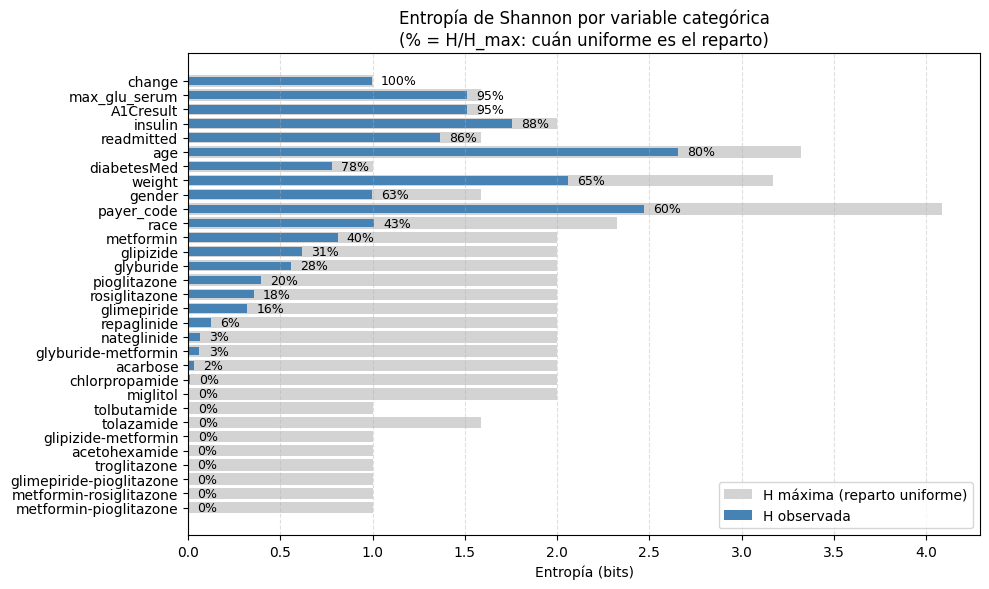

,n_categorias,H,H_max,Uniformidad (H/H_max),Cat_mas_frecuente,% de la moda
change,2,0.996,1.000,0.996,No,53.805
max_glu_serum,3,1.511,1.585,0.953,Norm,48.578
A1Cresult,3,1.510,1.585,0.952,>8,48.278
insulin,4,1.755,2.000,0.877,No,46.561
readmitted,3,1.364,1.585,0.860,NO,53.912
age,10,2.654,3.322,0.799,[70-80),25.616
diabetesMed,2,0.778,1.000,0.778,Yes,77.003
weight,9,2.056,3.170,0.649,[75-100),41.789
gender,3,0.996,1.585,0.629,Female,53.759
payer_code,17,2.468,4.087,0.604,MC,52.738


In [ ]:
#Entropia
entropia_categoricas(df)

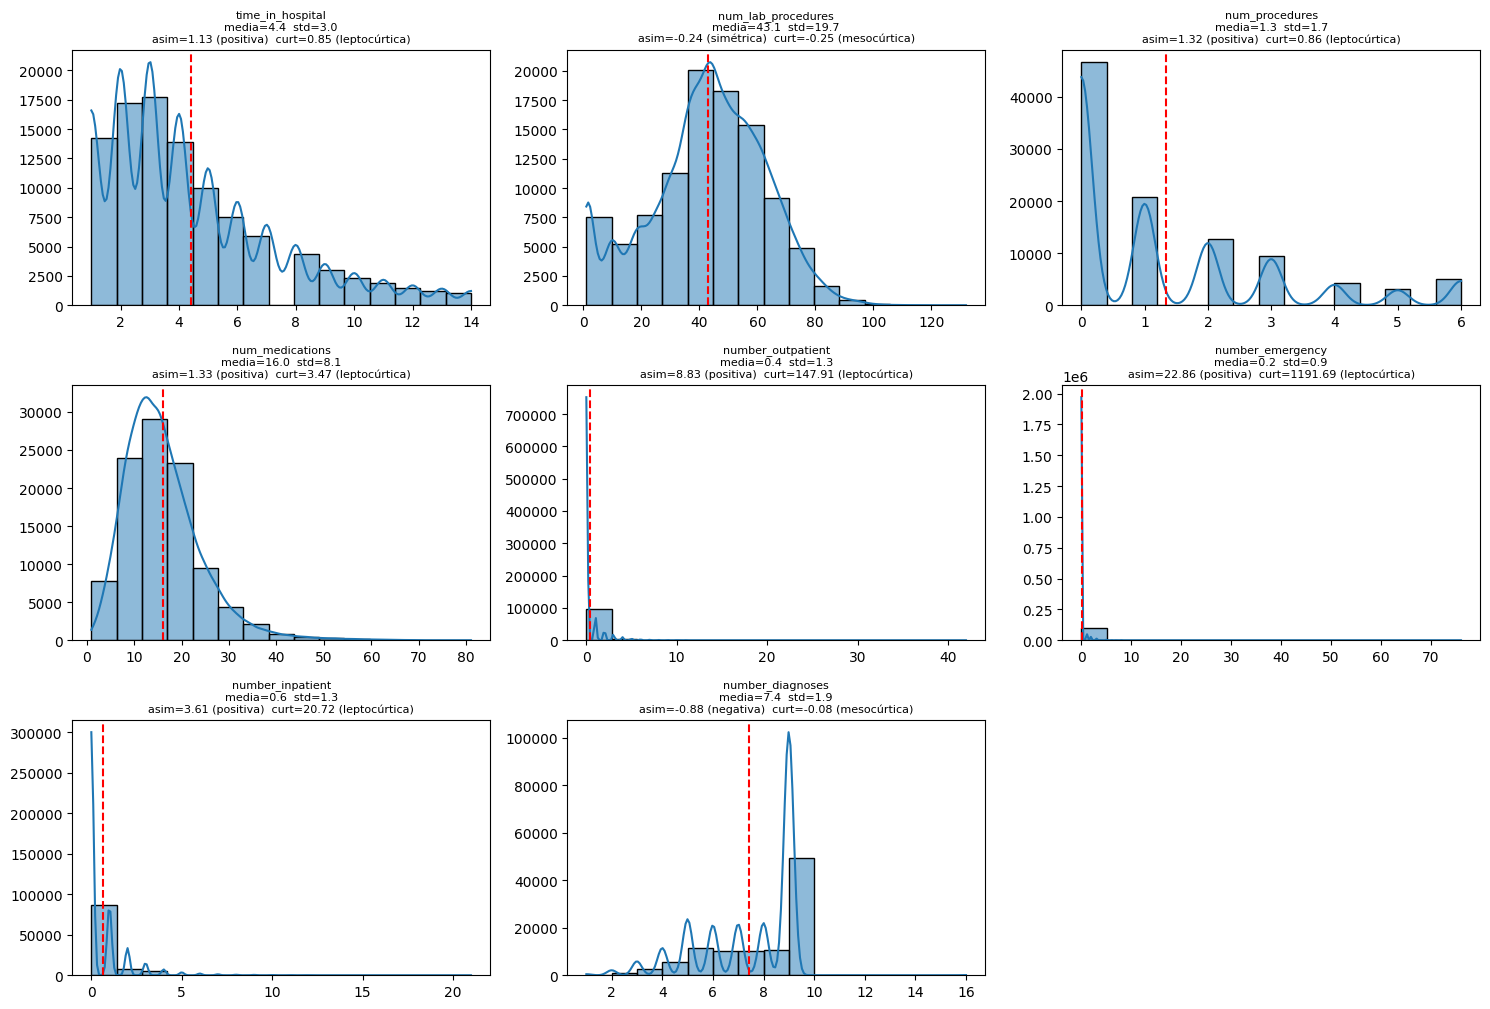

In [ ]:
#Analisis de variables numericas

grilla_histogramas(diab_df, num_int)

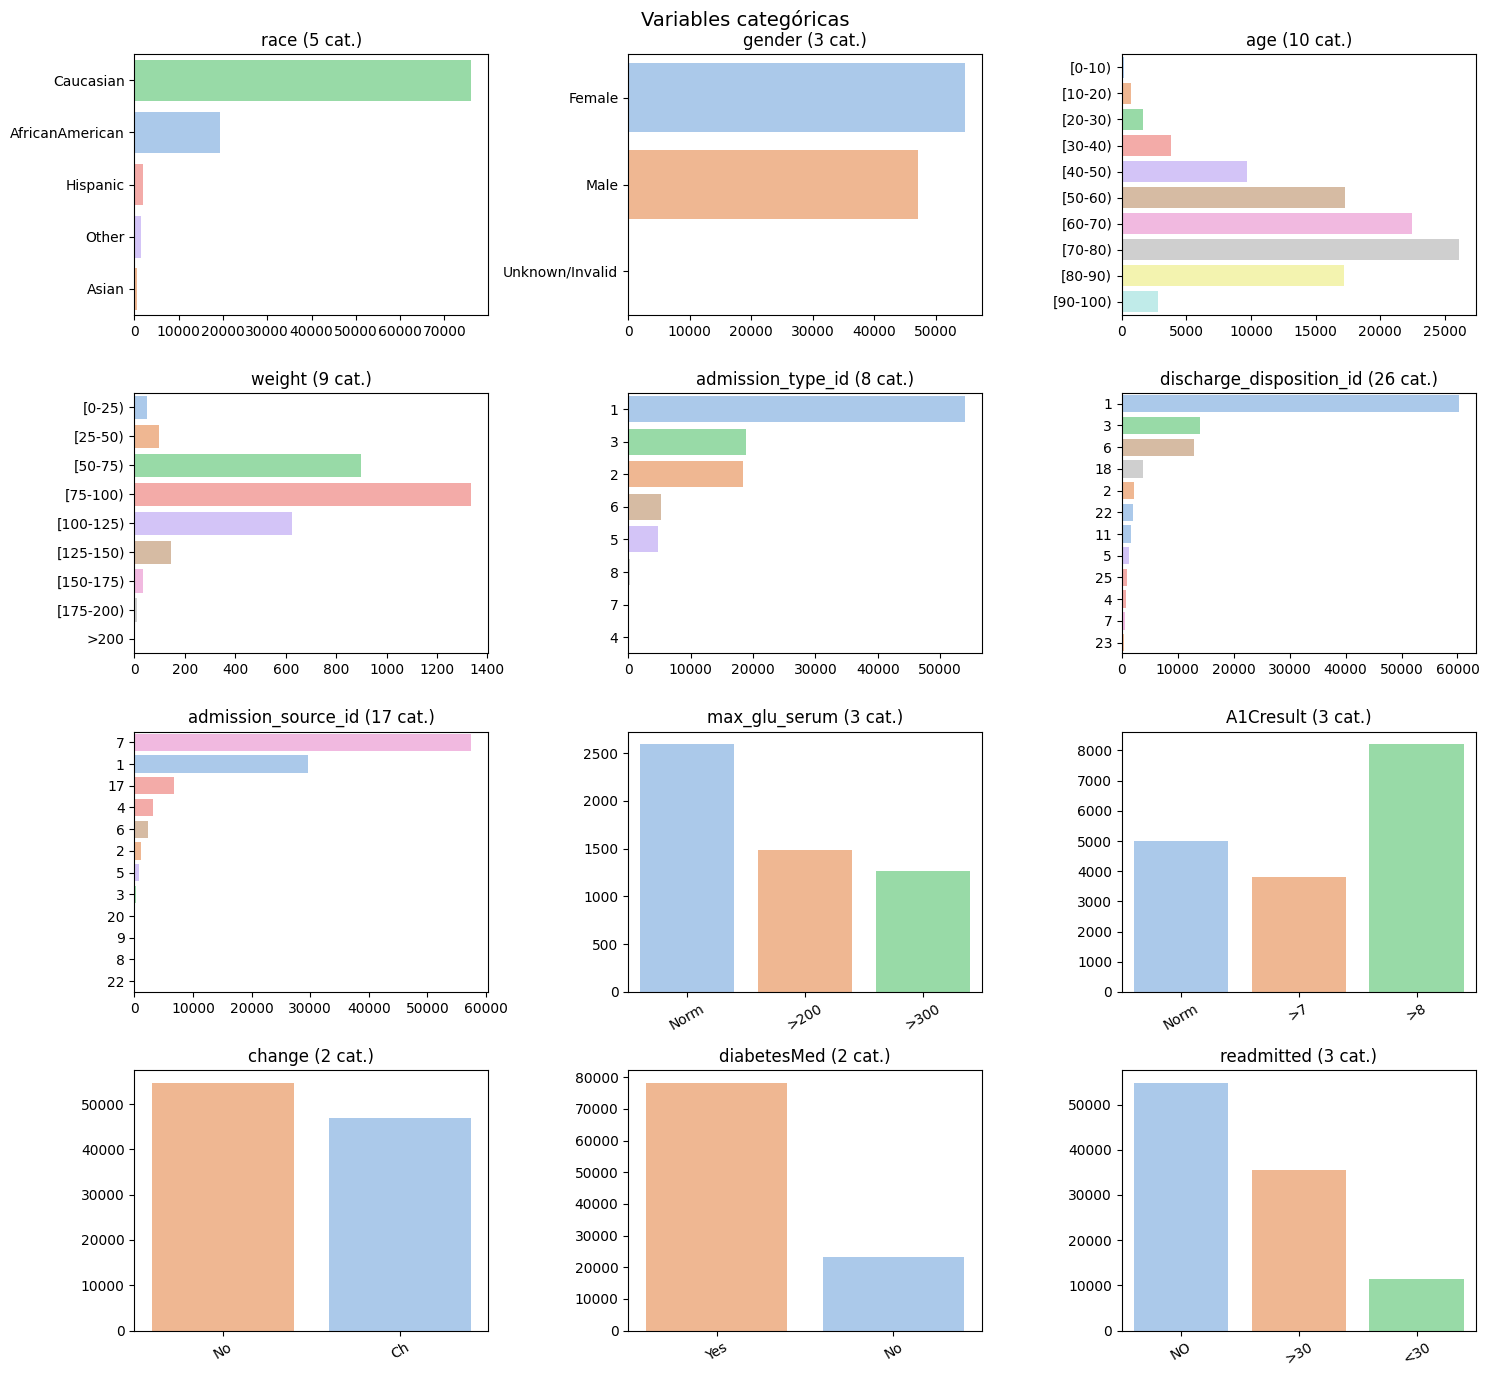

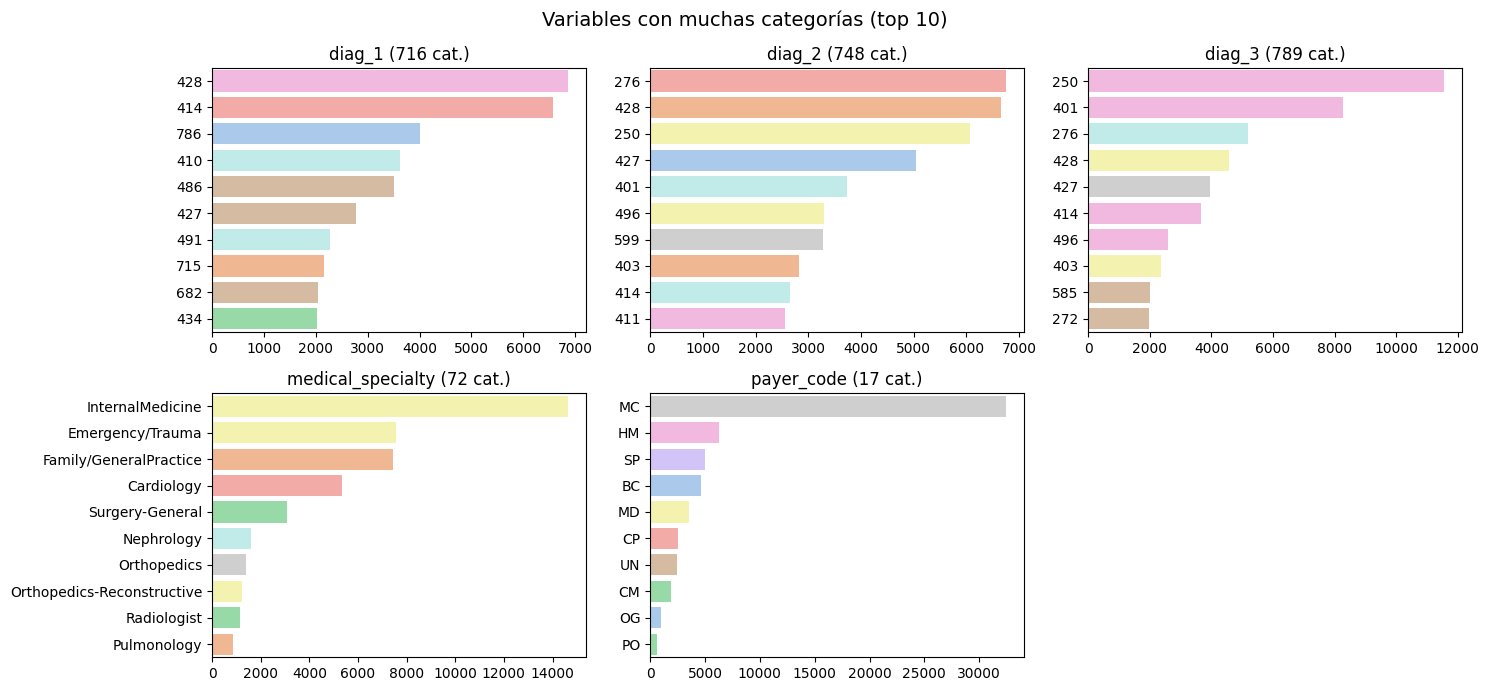

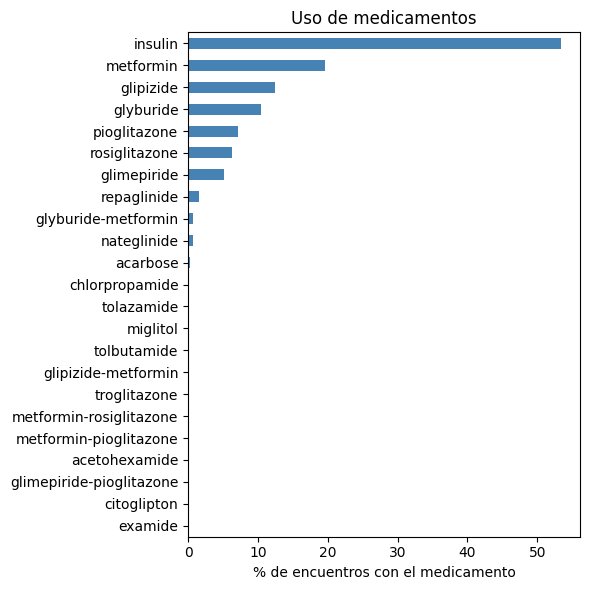

In [ ]:
# Analisis de las variables categorias

medicamentos = diab_df.loc[:, 'metformin':'metformin-pioglitazone'].columns.tolist()
muchas_cat = ['diag_1', 'diag_2', 'diag_3', 'medical_specialty', 'payer_code']
cat_cols = [c for c in diab_df.select_dtypes('category').columns
            if c not in medicamentos + muchas_cat]

# --- 2. Grilla de las categóricas "normales" (tu código, con top-N por seguridad) ---
def grilla_categoricas(data, cols, ncols=3, top=12, titulo=''):
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        s = data[col]
        orden = list(s.cat.categories) if s.cat.ordered else list(s.value_counts().head(top).index)
        horizontal = len(orden) > 6 or max(len(str(c)) for c in orden) > 12
        eje = {'y': col} if horizontal else {'x': col}
        sns.countplot(data=data, order=orden, hue=col, palette='pastel', legend=False, ax=ax, **eje)
        if not horizontal:
            ax.tick_params(axis='x', rotation=30)
        ax.set_title(f'{col} ({s.nunique()} cat.)'); ax.set_xlabel(''); ax.set_ylabel('')
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(titulo, fontsize=14); fig.tight_layout(); plt.show()

grilla_categoricas(diab_df, cat_cols, titulo='Variables categóricas')
grilla_categoricas(diab_df, muchas_cat, top=10, titulo='Variables con muchas categorías (top 10)')

# --- 3. Medicamentos: una sola barra con % de pacientes que los reciben ---
uso_med = diab_df[medicamentos].apply(lambda s: (s != 'No').mean() * 100).sort_values()
plt.figure(figsize=(6, 6))
uso_med.plot.barh(color='steelblue')
plt.xlabel('% de encuentros con el medicamento'); plt.title('Uso de medicamentos')
plt.tight_layout(); plt.show()

In [ ]:
#Valores faltantes
df = pd.read_csv(ruta, na_values=['?', 'None'])
falt = (df.isna().mean() * 100).round(2)
falt[falt > 0].sort_values(ascending=False)

/tmp/ipykernel_5463/3858381170.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, na_values=['?', 'None'])


,0
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


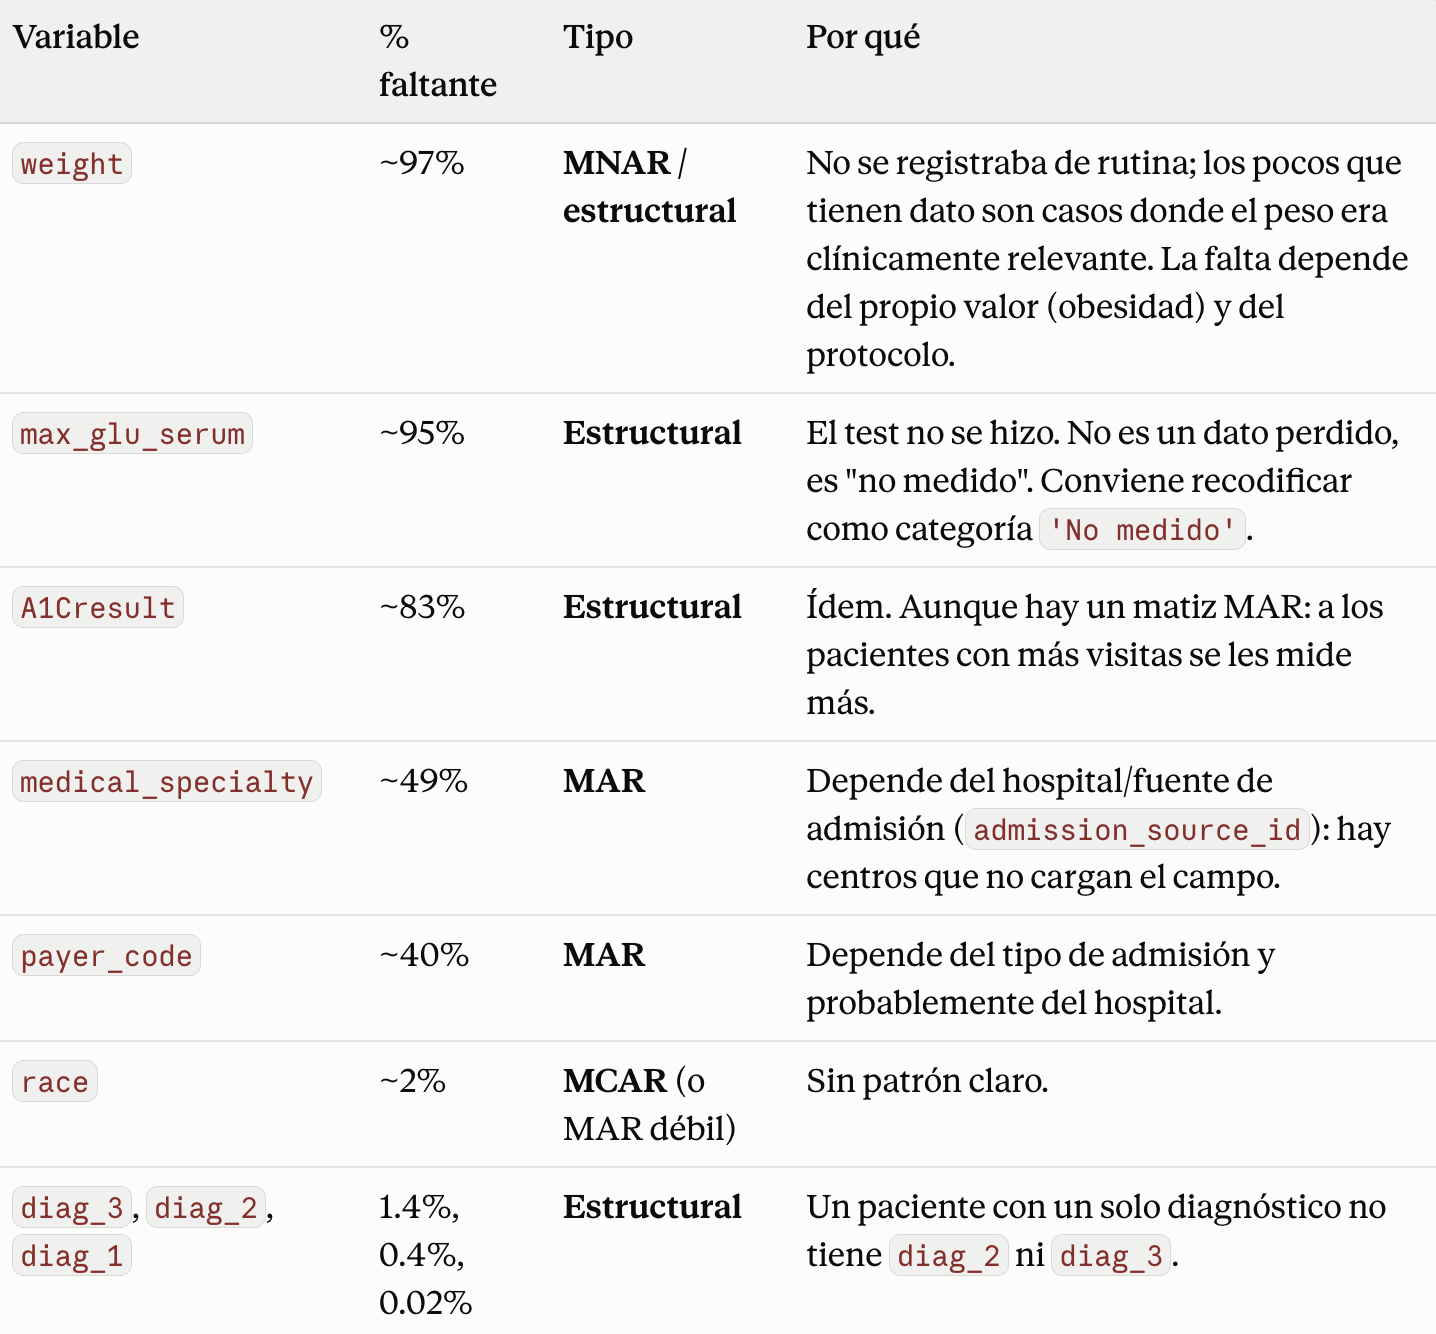

In [ ]:
# Outliers
num = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

def resumen_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    mask = (s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)
    return pd.Series({'n_out': mask.sum(), '%': round(mask.mean()*100, 2),
                      'max': s.max(), 'Q3': q3, 'asim': round(s.skew(), 2)})

df[num].apply(resumen_outliers).T

,n_out,%,max,Q3,asim
time_in_hospital,2252.0,2.21,14.0,6.0,1.13
num_lab_procedures,143.0,0.14,132.0,57.0,-0.24
num_procedures,4954.0,4.87,6.0,2.0,1.32
num_medications,2557.0,2.51,81.0,20.0,1.33
number_outpatient,16739.0,16.45,42.0,0.0,8.83
number_emergency,11383.0,11.19,76.0,0.0,22.86
number_inpatient,7049.0,6.93,21.0,1.0,3.61
number_diagnoses,281.0,0.28,16.0,9.0,-0.88


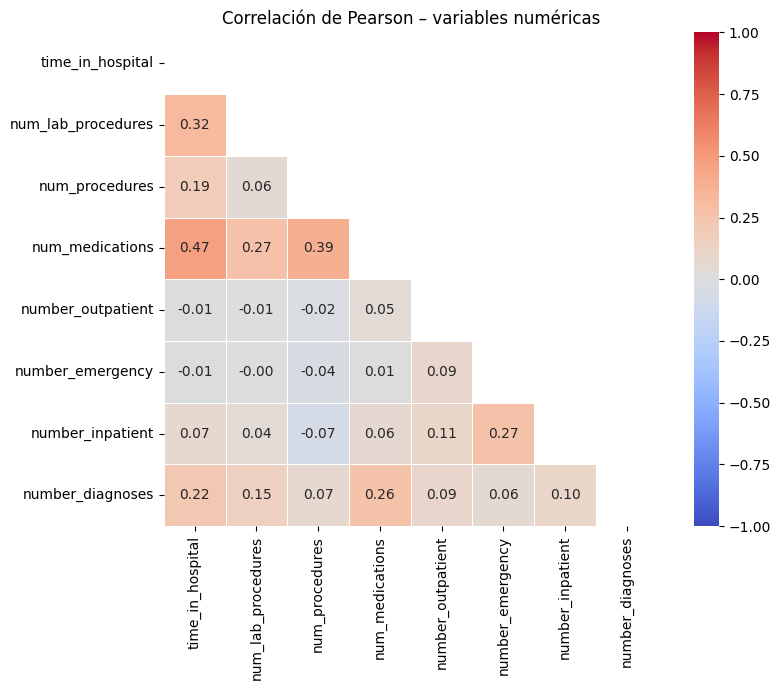

In [ ]:
#Relacion numerica-numerica

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

corr_pearson = diab_df[num_cols].astype(float).corr(method='pearson')

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Correlación de Pearson – variables numéricas')
plt.tight_layout();
plt.show()

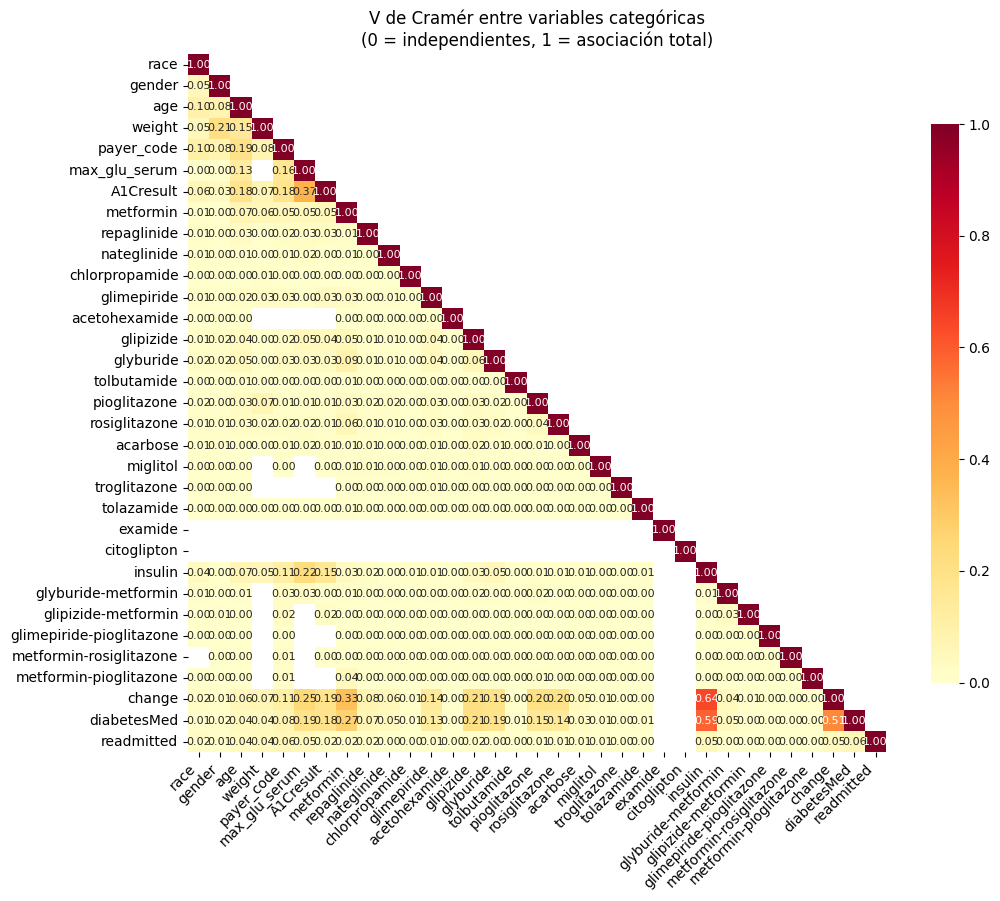

,race,gender,age,weight,payer_code,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
race,1.00,0.05,0.10,0.05,0.10,0.00,0.06,0.01,0.01,0.01,...,NaN,0.04,0.01,0.00,0.0,NaN,0.00,0.02,0.01,0.02
gender,0.05,1.00,0.08,0.21,0.08,0.00,0.03,0.00,0.00,0.00,...,NaN,0.00,0.00,0.01,0.0,0.00,0.00,0.01,0.02,0.01
age,0.10,0.08,1.00,0.15,0.19,0.13,0.18,0.07,0.03,0.01,...,NaN,0.07,0.01,0.00,0.0,0.00,0.00,0.06,0.04,0.04
weight,0.05,0.21,0.15,1.00,0.08,NaN,0.07,0.06,0.00,0.00,...,NaN,0.05,NaN,NaN,NaN,NaN,NaN,0.07,0.04,0.04
payer_code,0.10,0.08,0.19,0.08,1.00,0.16,0.18,0.05,0.02,0.01,...,NaN,0.11,0.03,0.02,0.0,0.01,0.01,0.11,0.08,0.06
max_glu_serum,0.00,0.00,0.13,NaN,0.16,1.00,0.37,0.05,0.03,0.02,...,NaN,0.22,0.03,NaN,NaN,NaN,NaN,0.25,0.19,0.05
A1Cresult,0.06,0.03,0.18,0.07,0.18,0.37,1.00,0.05,0.03,0.00,...,NaN,0.15,0.00,0.02,NaN,0.00,NaN,0.19,0.18,0.02
metformin,0.01,0.00,0.07,0.06,0.05,0.05,0.05,1.00,0.01,0.01,...,NaN,0.03,0.01,0.00,0.0,0.00,0.04,0.33,0.27,0.02
repaglinide,0.01,0.00,0.03,0.00,0.02,0.03,0.03,0.01,1.00,0.00,...,NaN,0.02,0.00,0.00,0.0,0.00,0.00,0.08,0.07,0.02
nateglinide,0.01,0.00,0.01,0.00,0.01,0.02,0.00,0.01,0.00,1.00,...,NaN,0.00,0.00,0.00,0.0,0.00,0.00,0.06,0.05,0.00


In [ ]:
#Relacion categorica-categorica

def _tabla_limpia(x, y):
    """Contingencia sin filas/columnas vacías (las categorías sin uso rompen el chi²)."""
    t = pd.crosstab(x, y)
    return t.loc[t.sum(axis=1) > 0, t.sum(axis=0) > 0]


def cramers_v(x, y, corregido=True):
    """V de Cramér con corrección de sesgo (Bergsma), que evita inflar el valor
    cuando hay muchas categorías."""
    t = _tabla_limpia(x, y)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return np.nan
    chi2 = st.chi2_contingency(t).statistic
    n = t.to_numpy().sum()
    phi2 = chi2 / n
    r, k = t.shape
    if corregido:
        phi2 = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
        r = r - (r - 1) ** 2 / (n - 1)
        k = k - (k - 1) ** 2 / (n - 1)
    denom = min(r - 1, k - 1)
    return np.sqrt(phi2 / denom) if denom > 0 else np.nan


def matriz_cramersv(data, columnas=None, figsize=(11, 9), mostrar=True, decimales=2):
    """Matriz de asociación entre todas las categóricas (análoga a .corr())."""
    if columnas is None:
        columnas = [c for c in data.select_dtypes(include=['category', 'object', 'bool']).columns
                    if data[c].nunique(dropna=True) <= 30]

    m = pd.DataFrame(np.eye(len(columnas)), index=columnas, columns=columnas)
    for i, a in enumerate(columnas):
        for b in columnas[i + 1:]:
            m.loc[a, b] = m.loc[b, a] = cramers_v(data[a], data[b])

    if mostrar:
        plt.figure(figsize=figsize)
        mascara = np.triu(np.ones_like(m, dtype=bool), k=1)
        sns.heatmap(m, annot=True, fmt=f'.{decimales}f', cmap='YlOrRd', vmin=0, vmax=1,
                    square=True, mask=mascara, annot_kws={'size': 8}, cbar_kws={'shrink': .8})
        plt.title("V de Cramér entre variables categóricas\n(0 = independientes, 1 = asociación total)")
        plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
        plt.tight_layout(); plt.show()

    return m.round(decimales)


matriz_cramersv(df)

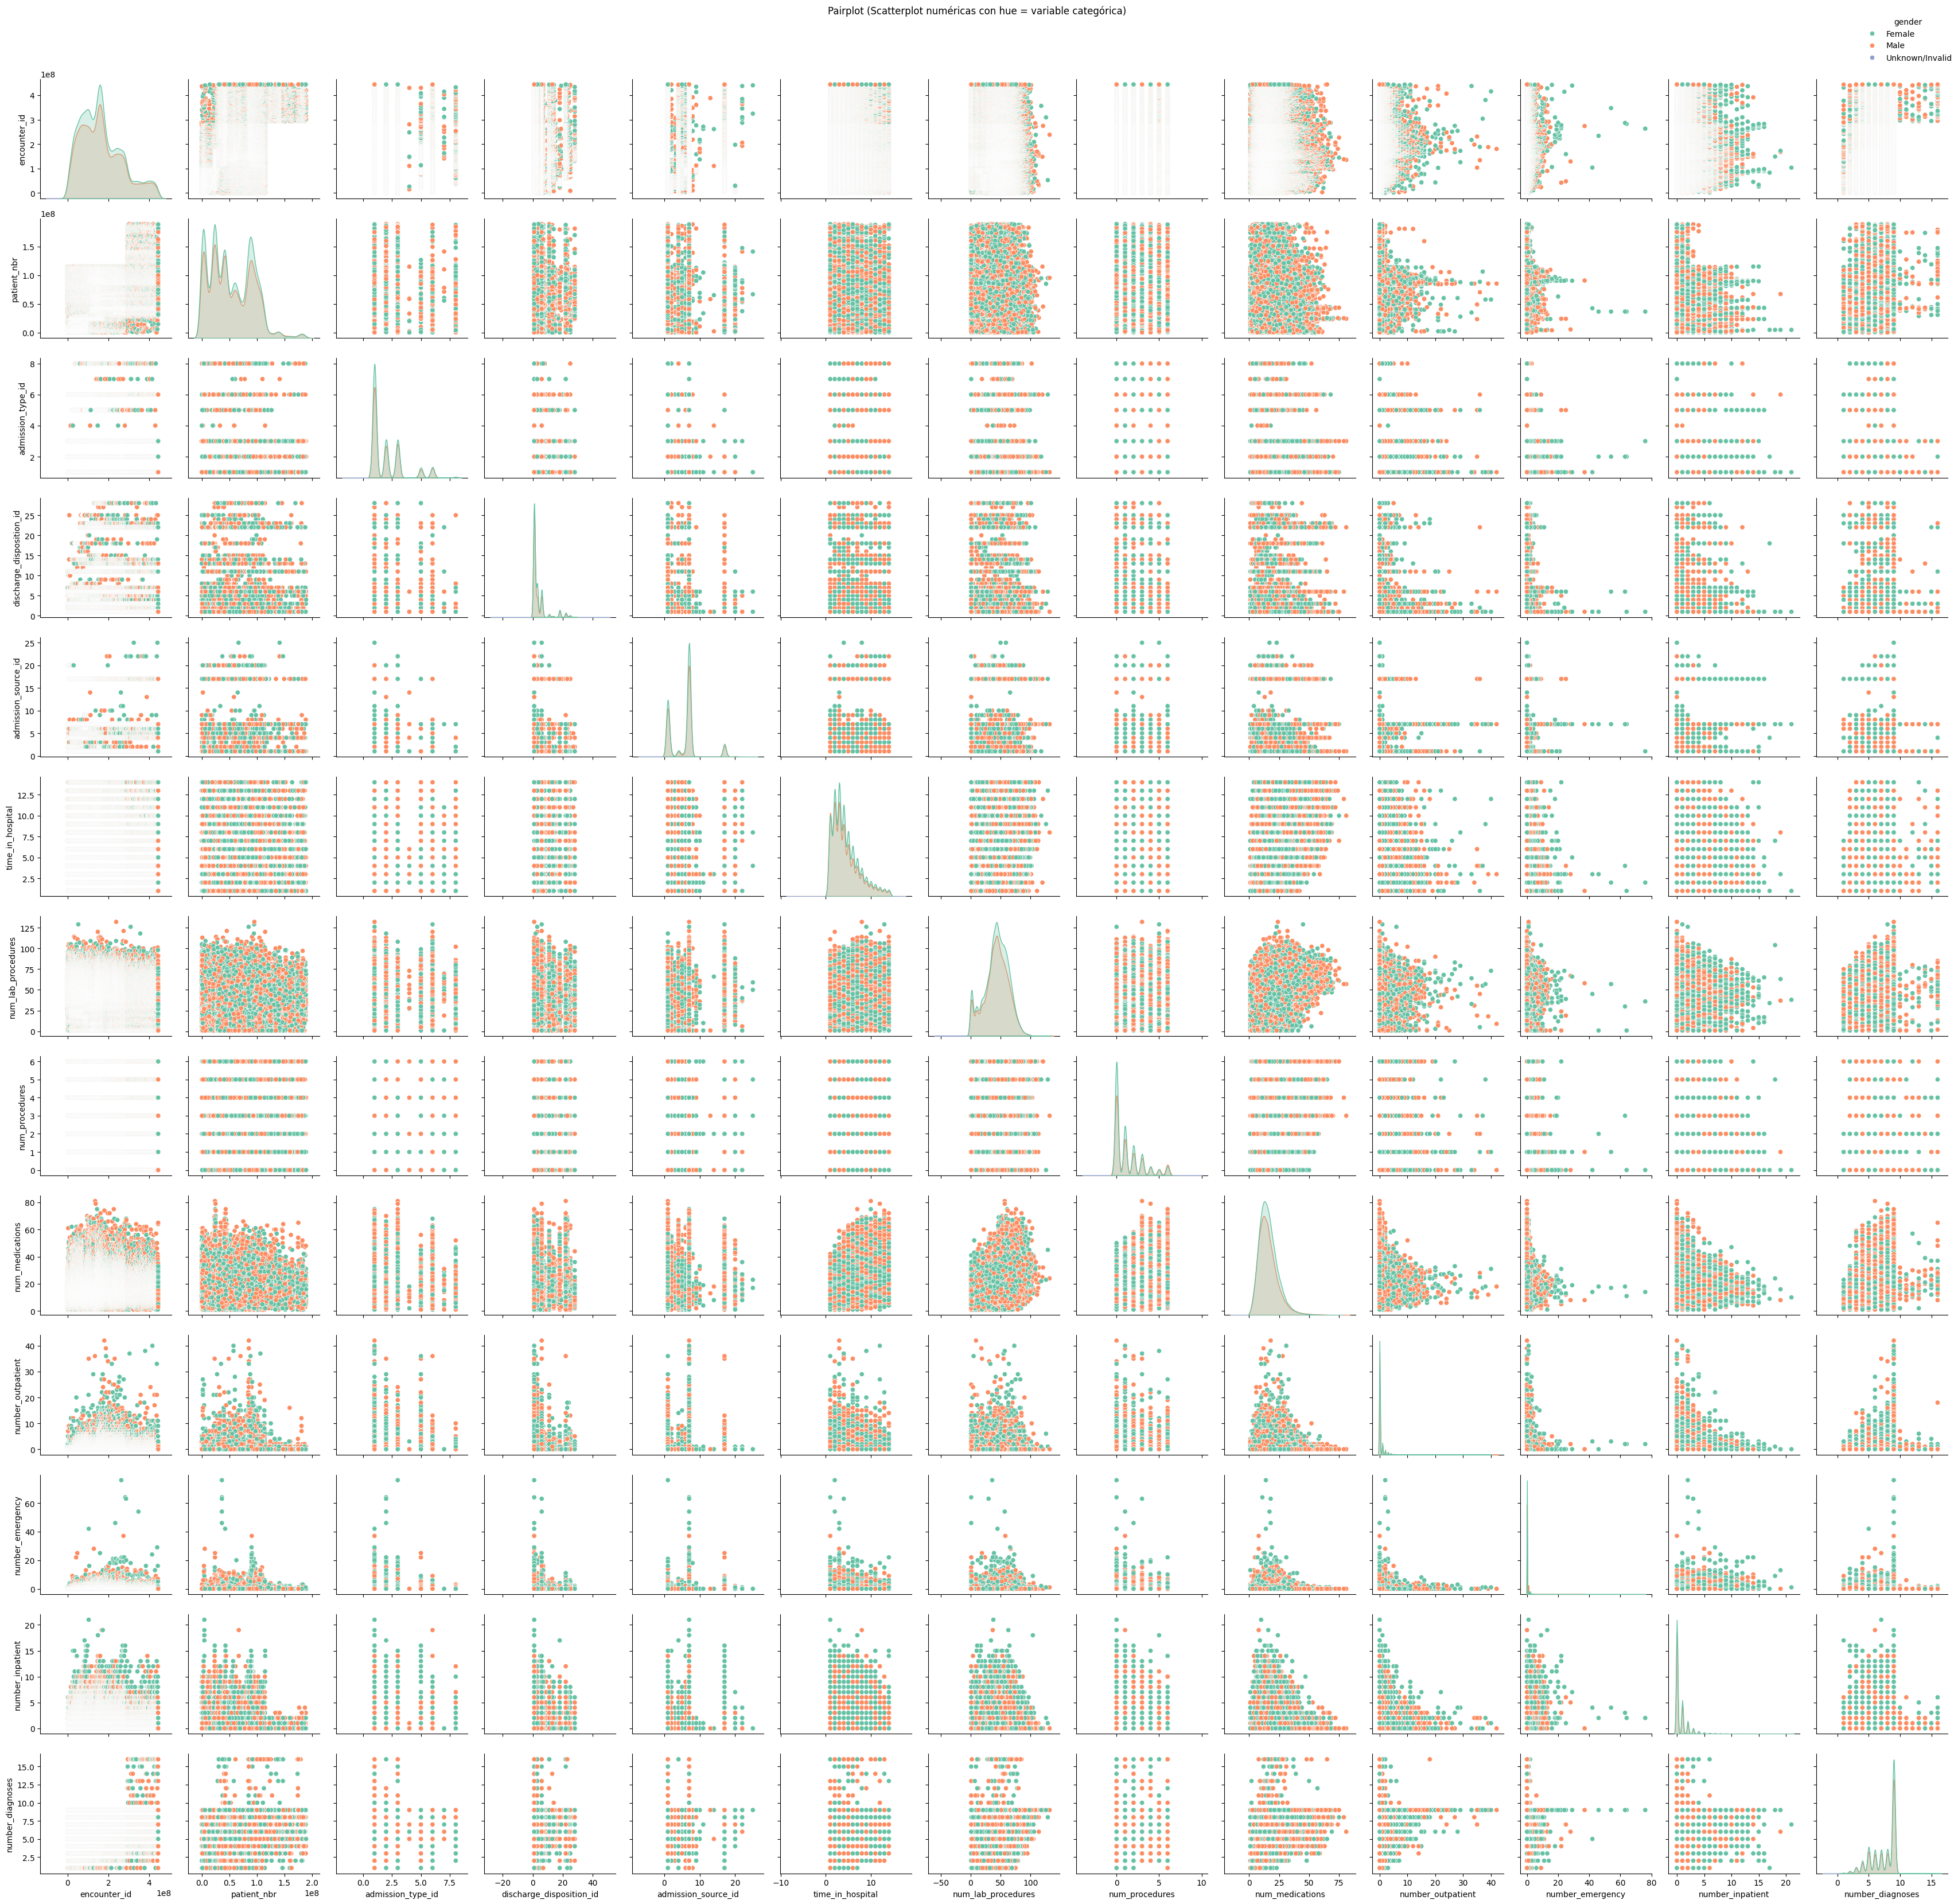

In [ ]:
#Relacion Numéricas-categóricas

# Se toma gender como parametro
grafico = sns.pairplot(data=df, hue='gender', palette='Set2')
grafico.figure.suptitle('Pairplot (Scatterplot numéricas con hue = variable categórica)', y=1.02)
grafico.legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()


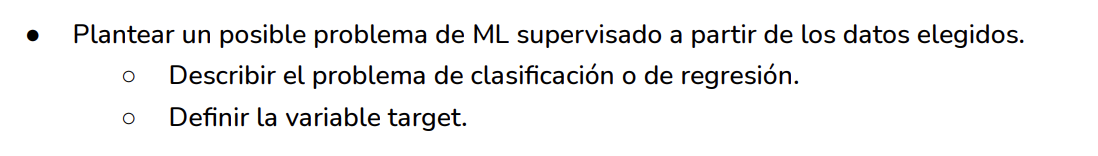


Problema de ML supervisado propuesto

Tipo: clasificación binaria.

Target: readmitted, recodificada como binaria: 1 si el paciente fue readmitido en menos de 30 días (<30), 0 en caso contrario (>30 o NO). Se elige el umbral de 30 días porque es el criterio que usan los sistemas de salud para penalizar readmisiones evitables, y porque las clases >30 y NO son clínicamente similares (el paciente no volvió en el corto plazo).

Unidad de análisis: cada fila es un encuentro hospitalario (una internación) de un paciente diabético.

Features: variables disponibles al momento del alta:

Del encuentro: time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_diagnoses, admission_type_id, admission_source_id, discharge_disposition_id, medical_specialty.
Historia previa: number_outpatient, number_emergency, number_inpatient (en el EDA son las que más se relacionan con la readmisión).
Paciente: age, gender, race.
Tratamiento: A1Cresult, max_glu_serum, insulin, metformin, change, diabetesMed, y las demás columnas de medicamentos con variabilidad.
Diagnósticos: diag_1, diag_2, diag_3, agrupados por capítulo ICD-9 (circulatorio, respiratorio, digestivo, diabetes, etc.) para reducir las cientos de categorías a unas 9.

Utilidad: identificar al alta a los pacientes con alto riesgo de volver, para asignarles seguimiento telefónico, control ambulatorio temprano o revisión de la medicación. Reducir readmisiones baja costos y mejora resultados clínicos.

Consideraciones surgidas del EDA:

Desbalance: solo ~11% de los encuentros son <30. Accuracy no sirve como métrica; hay que usar recall, precisión, F1 o AUC, y probablemente reponderar clases.
Filas a excluir: encuentros con discharge_disposition_id en {11, 19, 20, 21} (fallecidos o derivados a hospicio), que no pueden ser readmitidos y contaminan la clase 0.
Faltantes: weight se descarta (97% faltante). max_glu_serum y A1Cresult tienen faltantes estructurales (test no realizado) que se recodifican como categoría propia "no medido", no se imputan. medical_specialty y payer_code son MAR; se puede agregar una categoría "desconocido".
Columnas sin información: examide y citoglipton son constantes; encounter_id y patient_nbr son identificadores. Se eliminan.
Pacientes repetidos: ~30% de los pacientes tiene más de un encuentro. Para que train y test sean independientes, el split debe hacerse por patient_nbr, no por fila; si no, el modelo "ve" en test pacientes que ya conoce de train.
Outliers: los conteos de visitas previas tienen colas largas (hasta 76 visitas de emergencia). Son casos reales, no errores; conviene una transformación log o recortar en el percentil 99 antes de modelos sensibles a escala.
Variables categóricas con códigos numéricos: admission_type_id, discharge_disposition_id, admission_source_id deben tratarse como categóricas, no como números.

Alternativa de regresión, si la consigna pide plantear ambas: predecir time_in_hospital (1 a 14 días) a partir de las variables conocidas al ingreso, para planificar ocupación de camas. Del EDA: distribución asimétrica con moda en 2-3 días y correlación moderada con num_medications (r ≈ 0.47) y num_lab_procedures (r ≈ 0.32).